In [1]:
import pyccl as ccl
ccl.__version__
import numpy as np
import matplotlib.pylab as plt

x = np.arange(0,3072)

In [2]:
pz_path = '/home/s1/ggibbins/practice/lsst_like_dndz/' #where you saved the files from google drive

cosmo = ccl.Cosmology(Omega_c= 0.25, Omega_b=0.05, h=0.7, A_s=2.1e-9, n_s=0.96, Omega_k=0.0, w0 = -1, wa= 0.0, extra_parameters={"camb": {"dark_energy_model": "ppf"}})

nside = 1024
ell = np.arange(0,  3*nside+1)
bias_z = [1.0, 1.1, 1.2, 1.5, 2.0]

In [3]:
galtracers_dndz = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_lensgalaxies_bin_'+str(i)+'.npy')
    galtracers_dndz.append(nz)

galtracers_dndz = np.array(galtracers_dndz)

wltracers_dndz = []
for i in range(5):
    zz, nz = np.load(pz_path+'NZ_sourcegalaxies_bin_'+str(i)+'.npy')
    wltracers_dndz.append(nz)

wltracers_dndz = np.array(wltracers_dndz)

In [4]:
#CALCS AVG GAL PS FROM SIMULATED DATA W NOISE

gal_z0 = np.zeros(3072)
gal_z1 = np.zeros(3072)
gal_z2 = np.zeros(3072)
gal_z3 = np.zeros(3072)
gal_z4 = np.zeros(3072)

#Sepereates data into approp gal_z wrt z-bins with gal_z objs being 2000x3072 where rows are relizations and columns are ps values at same l value
for m in range(2000): #iterates through maps
    gal = np.load('noiseps/clgg_allz_'+str(m)+'.npy')
    z0, z1, z2, z3, z4 = gal
    gal_z0 = np.vstack((gal_z0, z0))
    gal_z1 = np.vstack((gal_z1, z1))
    gal_z2 = np.vstack((gal_z2, z2))
    gal_z3 = np.vstack((gal_z3, z3))
    gal_z4 = np.vstack((gal_z4, z4))

print(np.shape(gal_z0))

(2001, 3072)


In [5]:
#removes first row of zeros
gal_z0 = np.delete(gal_z0, 0, axis = 0)
gal_z1 = np.delete(gal_z1, 0, axis = 0)
gal_z2 = np.delete(gal_z2, 0, axis = 0)
gal_z3 = np.delete(gal_z3, 0, axis = 0)
c = np.delete(gal_z4, 0, axis = 0)

gal_mean_z0 = np.mean(gal_z0,axis=0)
gal_mean_z1 = np.mean(gal_z1,axis=0)
gal_mean_z2 = np.mean(gal_z2,axis=0)
gal_mean_z3 = np.mean(gal_z3,axis=0)
gal_mean_z4 = np.mean(gal_z4,axis=0)

gal_noisy_all = [gal_mean_z0,gal_mean_z1,gal_mean_z2,gal_mean_z3,gal_mean_z4]
# for l in range(3072):
#     gal_mean_z0.append(np.mean(gal_z0[:,l]))
#     gal_mean_z1.append(np.mean(gal_z1[:,l]))
#     gal_mean_z2.append(np.mean(gal_z2[:,l]))
#     gal_mean_z3.append(np.mean(gal_z3[:,l]))
#     gal_mean_z4.append(np.mean(gal_z4[:,l]))

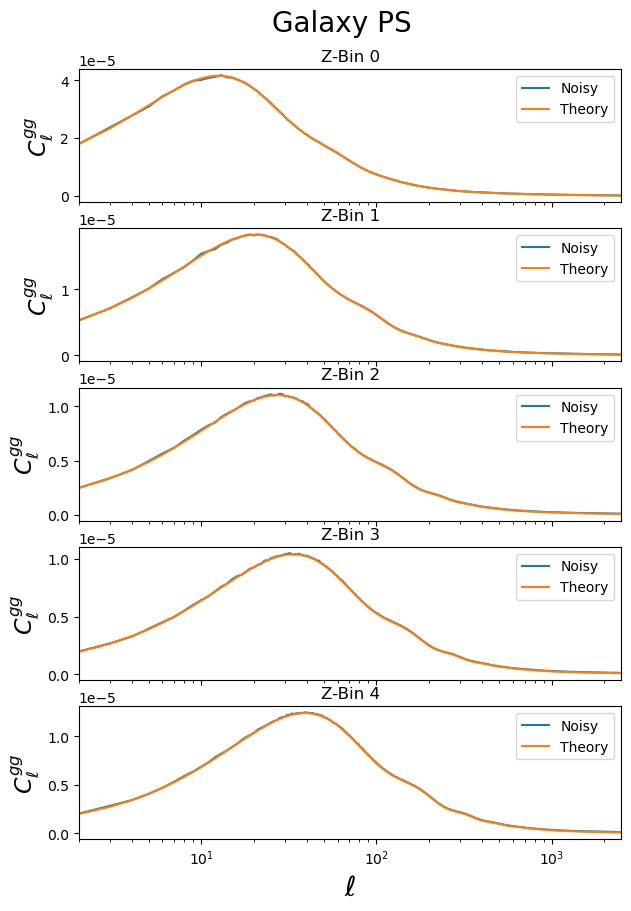

In [32]:
#PLOTS AVG GAL PS

fig, axs = plt.subplots(5,sharex=True, figsize=(7,10))
fig.suptitle("Galaxy PS", fontsize=20, y = .94)

plt.xscale('log')

plt.xlabel(r'$\ell$', fontsize=20)

for z in range(5):
    axs[z].set_title("Z-Bin "+str(z))
    axs[z].set_ylabel(r'$C_{\ell}^{gg}$', fontsize=17)
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[z]), bias= (zz,  bias_z[z]*np.ones(len(zz))))
    gal_auto = ccl.angular_cl(cosmo, gal, gal, x)
    
    axs[z].plot(x, gal_noisy_all[z], label = 'Noisy')
    axs[z].plot(gal_auto, label='Theory' )

    axs[z].set_xlim(2,2500)
    axs[z].legend()

plt.savefig('/home/s1/ggibbins/varyparams/noisecheckplots/gal')

In [7]:
#CALCS AVG WL PS FROM SIMULATED DATA W NOISE

wl_z0 = np.zeros(3072)
wl_z1 = np.zeros(3072)
wl_z2 = np.zeros(3072)
wl_z3 = np.zeros(3072)
wl_z4 = np.zeros(3072)

#Sepereates data into approp gal_z wrt z-bins with gal_z objs being 2000x3072 where rows are relizations and columns are ps values at same l value
for m in range(2000): #iterates through maps
    wl = np.load('noiseps/clkkgal_allz_'+str(m)+'.npy')
    z0, z1, z2, z3, z4 = wl
    wl_z0 = np.vstack((wl_z0, z0))
    wl_z1 = np.vstack((wl_z1, z1))
    wl_z2 = np.vstack((wl_z2, z2))
    wl_z3 = np.vstack((wl_z3, z3))
    wl_z4 = np.vstack((wl_z4, z4))

#removes first row of zeros
wl_z0 = np.delete(wl_z0, 0, axis = 0)
wl_z1 = np.delete(wl_z1, 0, axis = 0)
wl_z2 = np.delete(wl_z2, 0, axis = 0)
wl_z3 = np.delete(wl_z3, 0, axis = 0)
wl_z4 = np.delete(wl_z4, 0, axis = 0)

wl_mean_z0 = np.mean(wl_z0,axis=0)
wl_mean_z1 = np.mean(wl_z1,axis=0)
wl_mean_z2 = np.mean(wl_z2,axis=0)
wl_mean_z3 = np.mean(wl_z3,axis=0)
wl_mean_z4 = np.mean(wl_z4,axis=0)

wl_noisy_all = [wl_mean_z0,wl_mean_z1,wl_mean_z2,wl_mean_z3,wl_mean_z4]

In [24]:
# wl_noisy_mean = []
# for m in range(2000): #iterates through maps
#     wl_new = np.load('noiseps/clkkgal_allz_'+str(m)+'.npy')
#     #wl[z] = np.delete(wl[0], 0, axis = 0)
#     mean = np.mean(wl_new, axis = 0)
#     wl_noisy_mean.append(mean)

# if wl_noisy_all == wl_noisy_mean:
#     print('True')

In [27]:

# plt.plot(x, wl_noisy_all[0], label = 'bad code')
# plt.xscale('log')
# plt.plot(x, wl_noisy_mean[0], label = 'new')
# plt.legend()
# plt.xscale('log')

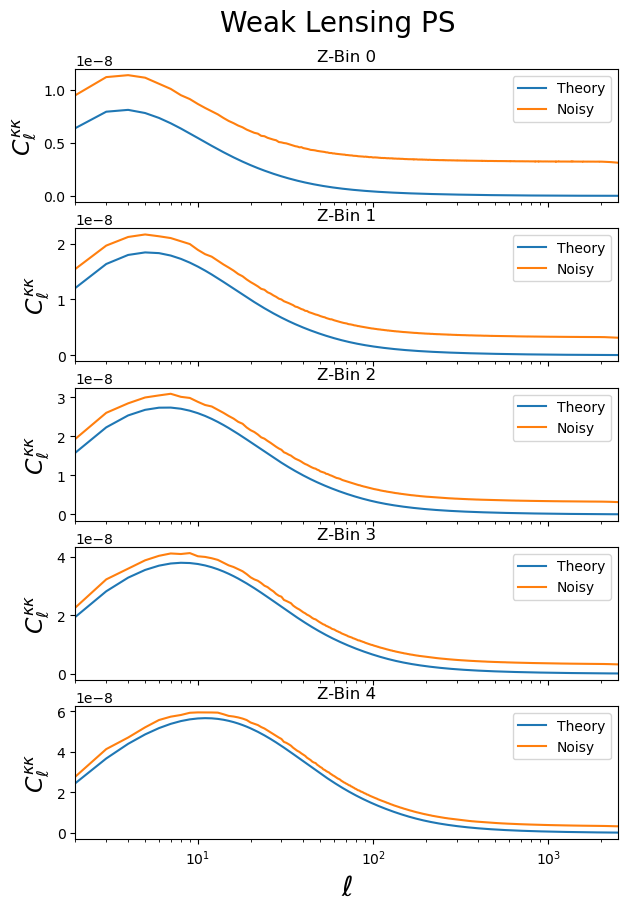

In [33]:
#PLOTS AVG WL PS

fig, axs = plt.subplots(5,sharex=True, figsize=(7,10))
fig.suptitle("Weak Lensing PS", fontsize=20, y = .94)
plt.xscale('log')

plt.xlabel(r'$\ell$', fontsize=20)

for z in range(5):
    axs[z].set_title("Z-Bin "+str(z))

#Iterates through oc list to create a cross ps for each value
for z in range(5): #iterates thru z bins
    axs[z].set_ylabel(r'$C_{\ell}^{\kappa\kappa}$', fontsize=17)
    axs[z].set_title("Z-Bin "+str(z))
    lens = ccl.WeakLensingTracer(cosmo, (zz,wltracers_dndz[z]))
    lens_auto = ccl.angular_cl(cosmo, lens, lens, ell)
    axs[z].plot(ell, lens_auto, label='Theory')
    axs[z].plot(x, wl_noisy_all[z], label='Noisy')
    axs[z].legend()
    axs[z].set_xlim(2,2500)

plt.savefig('/home/s1/ggibbins/varyparams/noisecheckplots/wl')

In [10]:
#CALCS AVG GAL x CMB PS FROM SIMULATED DATA W NOISE

gcmb_z0 = np.zeros(3072)
gcmb_z1 = np.zeros(3072)
gcmb_z2 = np.zeros(3072)
gcmb_z3 = np.zeros(3072)
gcmb_z4 = np.zeros(3072)

#Sepereates data into approp gal_z wrt z-bins with gal_z objs being 2000x3072 where rows are relizations and columns are ps values at same l value
for m in range(2000): #iterates through maps
    gcmb = np.load('noiseps/clkcmbg_allz_'+str(m)+'.npy')
    z0, z1, z2, z3, z4 = gcmb
    gcmb_z0 = np.vstack((gcmb_z0, z0))
    gcmb_z1 = np.vstack((gcmb_z1, z1))
    gcmb_z2 = np.vstack((gcmb_z2, z2))
    gcmb_z3 = np.vstack((gcmb_z3, z3))
    gcmb_z4 = np.vstack((gcmb_z4, z4))

#removes first row of zeros
gcmb_z0 = np.delete(gcmb_z0, 0, axis = 0)
gcmb_z1 = np.delete(gcmb_z1, 0, axis = 0)
gcmb_z2 = np.delete(gcmb_z2, 0, axis = 0)
gcmb_z3 = np.delete(gcmb_z3, 0, axis = 0)
gcmb_z4 = np.delete(gcmb_z4, 0, axis = 0)


gcmb_mean_z0 = np.mean(gcmb_z0,axis=0)
gcmb_mean_z1 = np.mean(gcmb_z1,axis=0)
gcmb_mean_z2 = np.mean(gcmb_z2,axis=0)
gcmb_mean_z3 = np.mean(gcmb_z3,axis=0)
gcmb_mean_z4 = np.mean(gcmb_z4,axis=0)

gcmb_noisy_all = [gcmb_mean_z0,gcmb_mean_z1,gcmb_mean_z2,gcmb_mean_z3,gcmb_mean_z4]

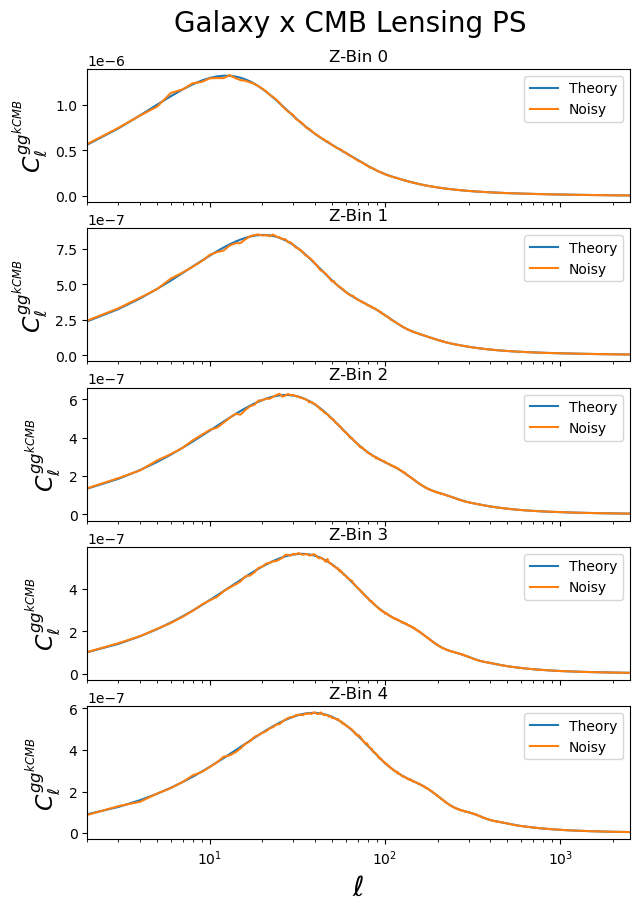

In [35]:
#PLOTS AVG GAL x CMB PS FROM SIMULATED DATA W NOISE

fig, axs = plt.subplots(5,sharex=True, figsize=(7,10))
fig.suptitle("Galaxy x CMB Lensing PS", fontsize=20, y = .94)
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=20)

for z in range(5):
    axs[z].set_title("Z-Bin "+str(z))
    axs[z].set_ylabel(r'$C_{\ell}^{gg^{kCMB}}$', fontsize=17)
    gal = ccl.NumberCountsTracer(cosmo,False,(zz,galtracers_dndz[z]), bias= (zz,  bias_z[z]*np.ones(len(zz))))
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    gal_cmb = ccl.angular_cl(cosmo, gal, cmb_lensing, x)
    axs[z].plot(x, gal_cmb, label='Theory')
    axs[z].plot(x, gcmb_noisy_all[z], label='Noisy')
    axs[z].legend()
    axs[z].set_xlim(2,2500)

plt.savefig('/home/s1/ggibbins/varyparams/noisecheckplots/gal_cmb')

In [12]:
#CALCS AVG WL x CMB PS FROM SIMULATED DATA W NOISE

wlcmb_z0 = np.zeros(3072)
wlcmb_z1 = np.zeros(3072)
wlcmb_z2 = np.zeros(3072)
wlcmb_z3 = np.zeros(3072)
wlcmb_z4 = np.zeros(3072)

#Sepereates data into approp gal_z wrt z-bins with gal_z objs being 2000x3072 where rows are relizations and columns are ps values at same l value
for m in range(2000): #iterates through maps
    wlcmb = np.load('noiseps/clkcmbkgal_allz_'+str(m)+'.npy',)
    z0, z1, z2, z3, z4 = wlcmb
    wlcmb_z0 = np.vstack((wlcmb_z0, z0))
    wlcmb_z1 = np.vstack((wlcmb_z1, z1))
    wlcmb_z2 = np.vstack((wlcmb_z2, z2))
    wlcmb_z3 = np.vstack((wlcmb_z3, z3))
    wlcmb_z4 = np.vstack((wlcmb_z4, z4))

#removes first row of zeros
wlcmb_z0 = np.delete(wlcmb_z0, 0, axis = 0)
wlcmb_z1 = np.delete(wlcmb_z1, 0, axis = 0)
wlcmb_z2 = np.delete(wlcmb_z2, 0, axis = 0)
wlcmb_z3 = np.delete(wlcmb_z3, 0, axis = 0)
wlcmb_z4 = np.delete(wlcmb_z4, 0, axis = 0)

#UNCOMMENT AND SAVE THIS AT SOME POINT -- full is 10000 ps realizations x 3072 cl values at l modes mtx (first 2000 z-bin 0 and so one)
#full = np.concatenate((wlcmb_z0, wlcmb_z1, wlcmb_z2, wlcmb_z3, wlcmb_z4), axis=0)
#np.save('/home/s1/ggibbins/varyparams/noisecl/'+'wlcmb.npy', full)

wlcmb_mean_z0 = np.mean(wlcmb_z0,axis=0)
wlcmb_mean_z1 = np.mean(wlcmb_z1,axis=0)
wlcmb_mean_z2 = np.mean(wlcmb_z2,axis=0)
wlcmb_mean_z3 = np.mean(wlcmb_z3,axis=0)
wlcmb_mean_z4 = np.mean(wlcmb_z4,axis=0)

wlcmb_noisy_all = [wlcmb_mean_z0,wlcmb_mean_z1,wlcmb_mean_z2,wlcmb_mean_z3,wlcmb_mean_z4]


In [13]:
y = np.array([[0,1,2],[3,4,5]])
print(y)
mean = np.mean(y, axis=0)
print(mean)

[[0 1 2]
 [3 4 5]]
[1.5 2.5 3.5]


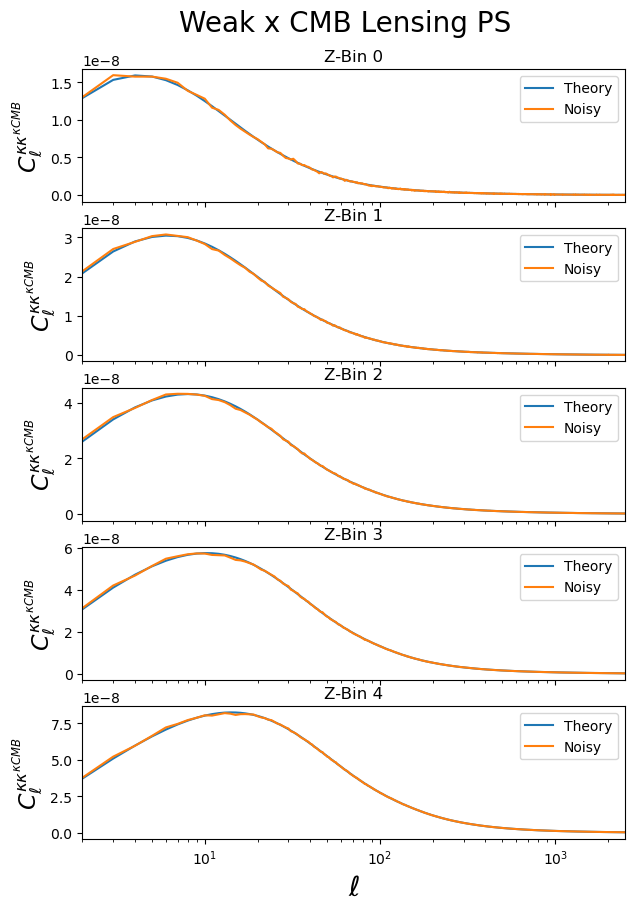

In [34]:
#PLOTS AVG WL x CMB PS FROM SIMULATED DATA W NOISE

fig, axs = plt.subplots(5,sharex=True, figsize=(7,10))
fig.suptitle("Weak x CMB Lensing PS", fontsize=20, y = .94)
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=20)

for z in range(5):
    axs[z].set_title("Z-Bin "+str(z))
    axs[z].set_ylabel(r'$C_{\ell}^{\kappa\kappa^{{\kappa}CMB}}$', fontsize=17)
    cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
    lens = ccl.WeakLensingTracer(cosmo, (zz, wltracers_dndz[z]))
    lens_cmb = ccl.angular_cl(cosmo, cmb_lensing, lens, ell)

    axs[z].plot(ell, lens_cmb, label='Theory')
    axs[z].plot(x, wlcmb_noisy_all[z], label='Noisy')
    axs[z].legend()
    axs[z].set_xlim(2,2500)

plt.savefig('/home/s1/ggibbins/varyparams/noisecheckplots/wl_cmb')

(5, 3072)


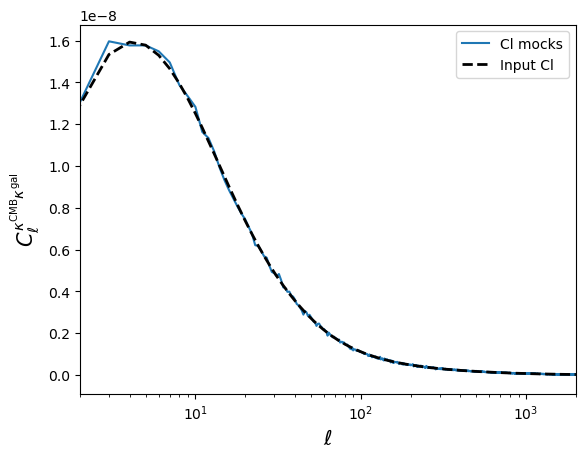

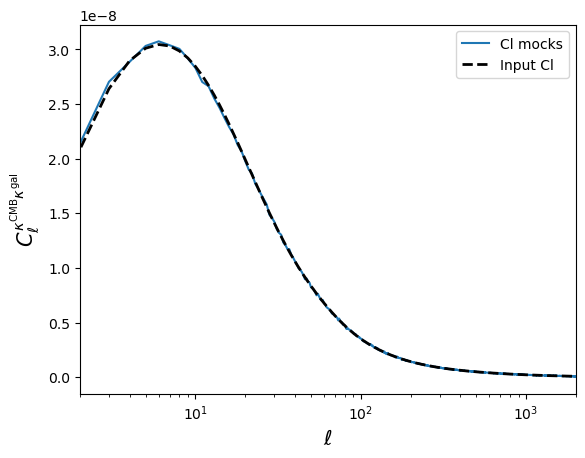

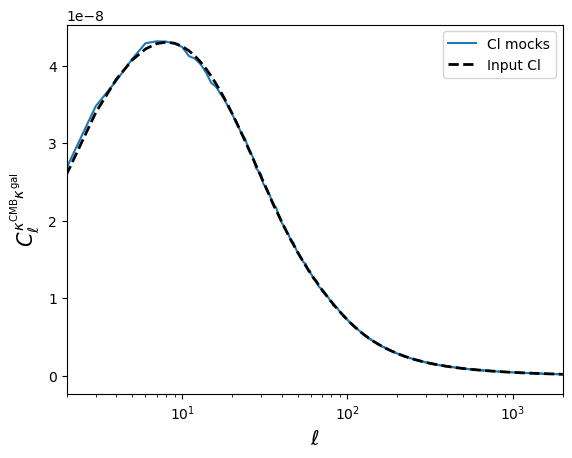

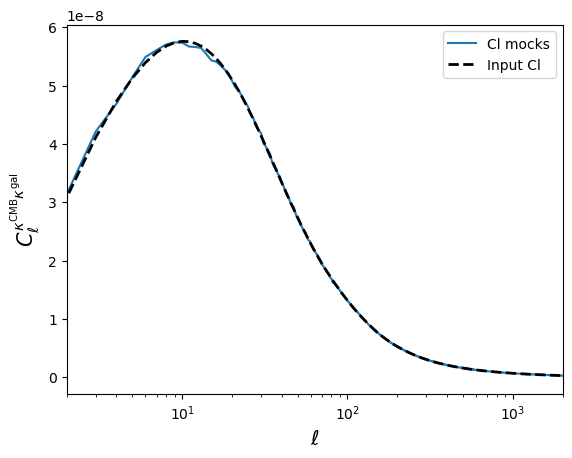

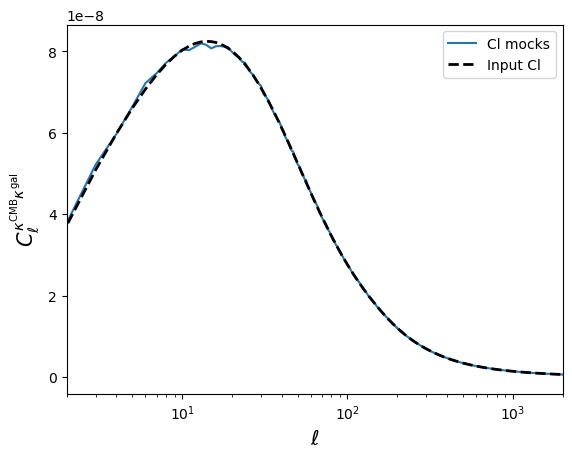

"\ncl_all = []\nfor nn in range(2000):\n    print(nn)\n    cl_out = np.load(path_cls +'clkkgal_allz_'+str(nn)+'.npy')\n    cl_all.append(cl_out)\nnp.save(some_path+'all_clkkgal_allbins.npy', np.array(cl_all))\n\n\nfor z in range(5):\n    cl_in =  np.load(path_in+'Clkk_z_'+str(z)+'_z_'+str(z)+'.npy')\n    plt.figure()\n    plt.plot(np.mean(np.array(cl_all)[:,z,:], axis=0), label='Cl mocks')\n    plt.plot(cl_in ,'--',color='k',lw=2, label='Input Cl')\n    plt.plot(cl_in+nl_gamma_noise,'--',color='k',lw=2, label='Input Cl + Noise')\n    plt.xscale('log')\n    plt.xlim(2,2000)\n    plt.legend()\n    plt.ylabel(r'$C_{\\ell}^{{\\kappa}^{\rm gal}\\kappa^{\rm gal}}$', fontsize=15)\n    plt.xlabel(r'$\\ell$',fontsize=15)\n    plt.show()\n"

In [21]:
##########GABRIELAS CODE

import numpy as np 
import matplotlib.pylab as plt 


path_cls = '/home/s1/ggibbins/varyparams/noiseps/' 
path_in = '/home/s1/gmarques/th_input/' # Edit here where you want to save it!
nside = 1024
sigmae= 0.26
ndensity= 1.78 #1/arcmin2)
nshear_str = ndensity/((np.pi/(180*60))**2)
nl_gamma_noise =  np.ones(3*nside+1)* ((0.26**2)/(nshear_str))

npix_lens =  [2.25, 3.11,3.09, 2.61, 2.0]
nbar_lens = [npix_lens[i]/((np.pi/(180*60))**2) for i in range(5)]
shotnoise_lens = [(1. / nbar_lens[i])*np.ones(3*nside+1)  for i in range(5)]


 
##############CL( KCMB X K GALS) ######################################
cl_all = []
for nn in range(2000):
    cl_out = np.load(path_cls +'clkcmbkgal_allz_'+str(nn)+'.npy')
    cl_all.append(cl_out)

#np.save(some_path+'all_clkcmbg_allbins.npy', np.array(cl_all))
print(cl_all[0].shape)
for z in range(5):
    cl_in =  np.load(path_in+'Clkcmbk_z_'+str(z)+'.npy')
    plt.figure()
    plt.plot(np.mean(np.array(cl_all)[:,z,:], axis=0), label='Cl mocks')
    plt.plot(cl_in ,'--',color='k',lw=2, label='Input Cl')
    plt.xscale('log')
    plt.xlim(2,2000)
    plt.legend()
    plt.ylabel(r'$C_{\ell}^{{\kappa}^{\rm CMB}\kappa^{\rm gal}}$', fontsize=15)
    plt.xlabel(r'$\ell$',fontsize=15)
    plt.show()
#    plt.savefig('path+nameoffile.png')

##############CL( KCMB X G) ######################################


##############CL(GG) ######################################

#shotnoise_lens is the importante one
##############CL(KK GALS) ######################################
'''
cl_all = []
for nn in range(2000):
    print(nn)
    cl_out = np.load(path_cls +'clkkgal_allz_'+str(nn)+'.npy')
    cl_all.append(cl_out)
np.save(some_path+'all_clkkgal_allbins.npy', np.array(cl_all))


for z in range(5):
    cl_in =  np.load(path_in+'Clkk_z_'+str(z)+'_z_'+str(z)+'.npy')
    plt.figure()
    plt.plot(np.mean(np.array(cl_all)[:,z,:], axis=0), label='Cl mocks')
    plt.plot(cl_in ,'--',color='k',lw=2, label='Input Cl')
    plt.plot(cl_in+nl_gamma_noise,'--',color='k',lw=2, label='Input Cl + Noise')
    plt.xscale('log')
    plt.xlim(2,2000)
    plt.legend()
    plt.ylabel(r'$C_{\ell}^{{\kappa}^{\rm gal}\kappa^{\rm gal}}$', fontsize=15)
    plt.xlabel(r'$\ell$',fontsize=15)
    plt.show()
'''

(2, 2000)

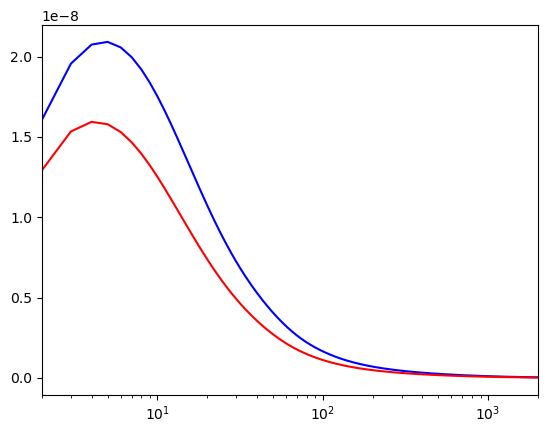

In [32]:
#from theory

cl0 =  np.load(path_in+'Clkcmbk_z_0.npy')

cmb_lensing = ccl.CMBLensingTracer(cosmo, 1100) #(cosmology, cmb redshift)
lens = ccl.WeakLensingTracer(cosmo, (zz,galtracers_dndz[0]))
lens_cmb = ccl.angular_cl(cosmo, cmb_lensing, lens, ell)

plt.plot(ell, lens_cmb, 'b') #my code

plt.plot(ell, cl0, 'r') #gabrielas code

plt.xscale('log')
plt.xlim(2,2000)